## Data lookup

In this we will take a look at data first. The data comes from udacity course, the task is to clasiffy the reviews. First we will import libraries and then look at basic info about data.

In [21]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("reviews.csv")
data.head(3)

,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1


In [3]:
print(data.shape)
print(data.info())

(18442, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              18442 non-null  int64 
 1   Age                      18442 non-null  int64 
 2   Title                    18442 non-null  object
 3   Review Text              18442 non-null  object
 4   Positive Feedback Count  18442 non-null  int64 
 5   Division Name            18442 non-null  object
 6   Department Name          18442 non-null  object
 7   Class Name               18442 non-null  object
 8   Recommended IND          18442 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.3+ MB
None


We should check if we have empties in the data

In [17]:
data.isna().sum()

Age                        0
Title                      0
Review Text                0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
Recommended IND            0
dtype: int64

Next, we will split the data for numerical, categorical and text. Also, I will drop the id column, because we will not use it for modelling.

In [4]:
num_cols = ["Age", "Positive Feedback Count", "Recommended IND"]
cat_cols = ["Division Name", "Department Name", "Class Name"]
text_cols = ["Title", "Review Text"]
data = data.drop(["Clothing ID"], axis = 1)

In [11]:
data_num = data[num_cols]
data_cat = data[cat_cols]
data_num_cat = pd.concat([data_num, data_cat], axis=1)

Let's look at distributions data

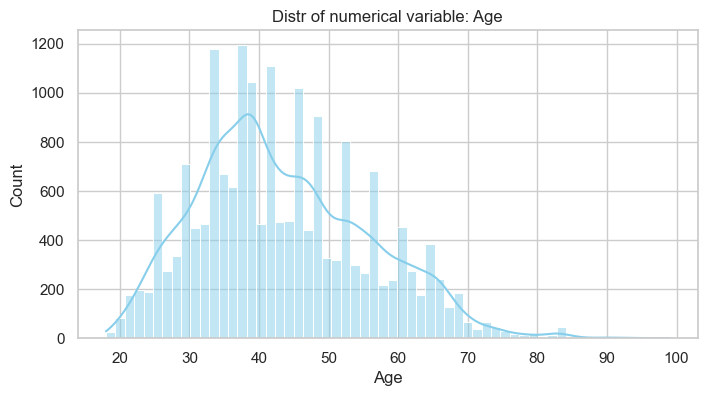

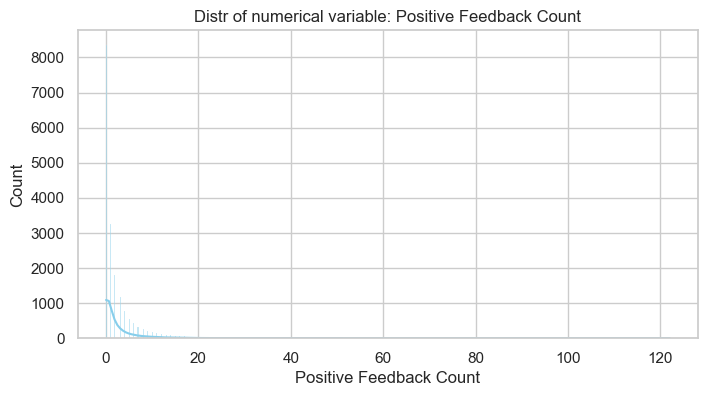

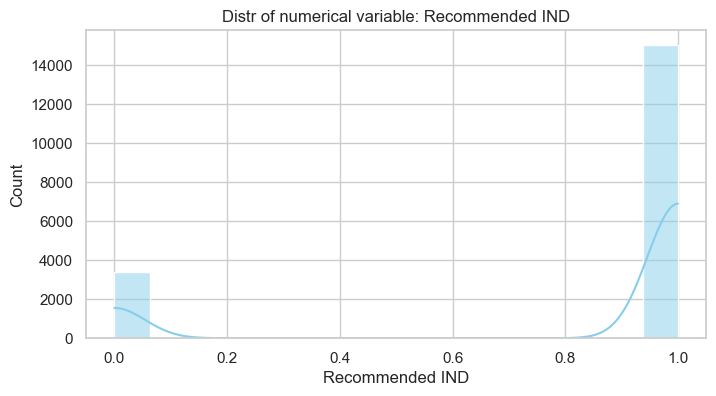

C:\Users\Maksym\AppData\Local\Temp\ipykernel_20880\530033577.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data_num_cat[col], palette='viridis')


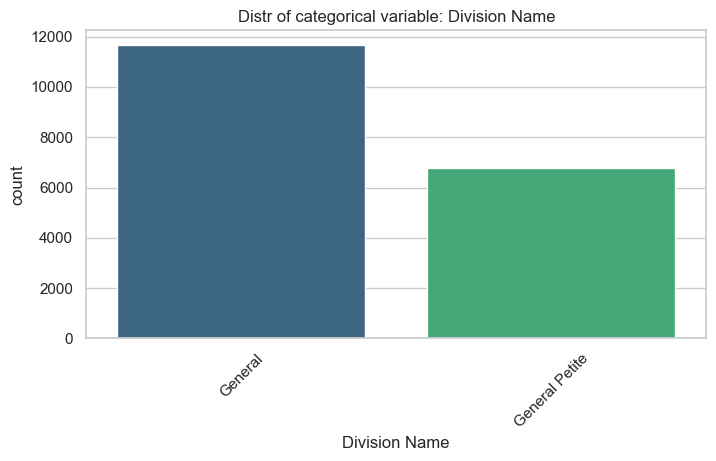

C:\Users\Maksym\AppData\Local\Temp\ipykernel_20880\530033577.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data_num_cat[col], palette='viridis')


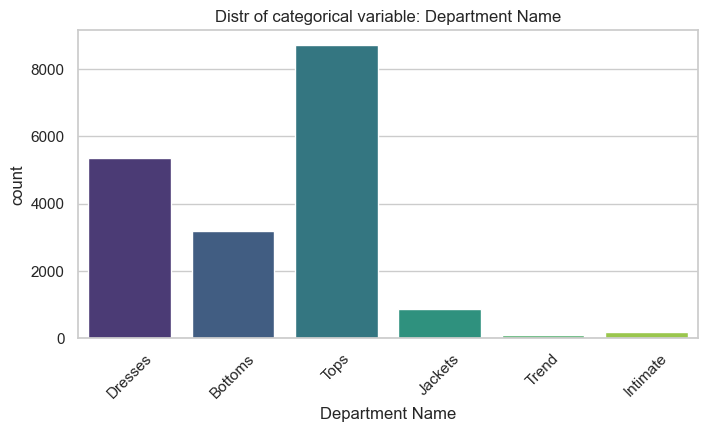

C:\Users\Maksym\AppData\Local\Temp\ipykernel_20880\530033577.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data_num_cat[col], palette='viridis')


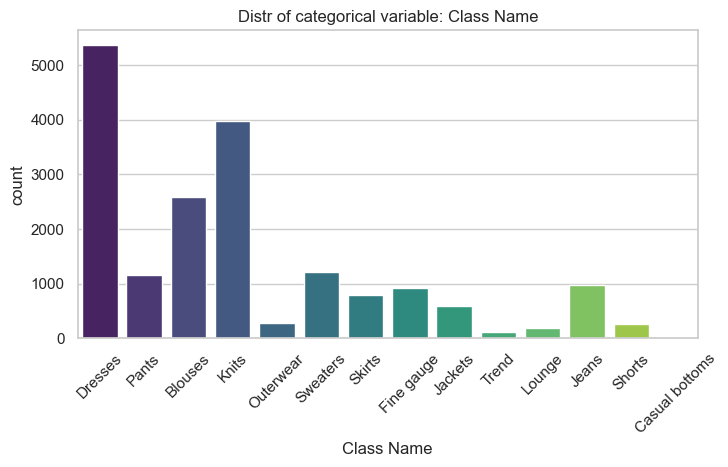

In [14]:
sns.set_theme(style="whitegrid")
for col in data_num_cat.columns:
    plt.figure(figsize=(8, 4))
    if pd.api.types.is_numeric_dtype(data_num_cat[col]):
        sns.histplot(data_num_cat[col], kde=True, color='skyblue')
        plt.title(f'Distr of numerical variable: {col}')
    else:
        sns.countplot(x=data_num_cat[col], palette='viridis')
        plt.xticks(rotation=45)
        plt.title(f'Distr of categorical variable: {col}')
    
    plt.show()

In [20]:
data["Review Text"][100]

"Ii'm not usually big on lace but this is so unique and versatile that i went for it. looks good dressed up w/a nice top or casual w/a tee. can be worn practically all year. love it!"